In [1]:
library(Seurat)
library(SummarizedExperiment)
library(SCopeLoomR)
library(AUCell)
library(SCENIC)
library(dplyr)
library(KernSmooth)
library(RColorBrewer)
library(plotly)
library(BiocParallel)
library(grid)
library(ComplexHeatmap)
library(data.table)
library(SCENIC)
library(loomR)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.5.2 but the current version is
4.5.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.7.4 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges

In [2]:
# loom <- open_loom('data/pySCENIC/rgc_pyscenic.loom')

# regulons_incidMat <- get_regulons(loom,column.attr.name="Regulons")
# regulons <- regulonsToGeneLists(regulons_incidMat)
# regulonAUC <- get_regulons_AUC(loom,column.attr.name='RegulonsAUC')
# regulonAucThresholds <- get_regulon_thresholds(loom)
# tail(regulonAucThresholds[order(as.numeric(names(regulonAucThresholds)))])
# embeddings <- get_embeddings(loom)  
# close_loom(loom)

# sce <- readRDS("data/snRNA_data/RGC.rds")
# sub_regulonAUC <- regulonAUC[,match(colnames(sce),colnames(regulonAUC))]
# cellTypes <- data.frame(row.names = colnames(sce), celltype = as.character(sce$C_scANVI))
# condition <- data.frame(row.names = colnames(sce), condition = sce$condition)
# save(sub_regulonAUC,cellTypes,condition,sce,file = 'data/pySCENIC/for_rss_and_visual.Rdata')

In [3]:
load('data/pySCENIC/for_rss_and_visual.Rdata')

In [4]:
selectedResolution <- "condition"
cellsPerGroup <- split(rownames(condition), condition[,selectedResolution]) 

In [5]:
sub_regulonAUC <- sub_regulonAUC[onlyNonDuplicatedExtended(rownames(sub_regulonAUC)),] 
dim(sub_regulonAUC)

[1]    22 13056

In [6]:
regulonActivity_byGroup <- sapply(cellsPerGroup,function(cells)rowMeans(getAUC(sub_regulonAUC)[,cells]))
regulonActivity_byGroup_Scaled <- t(scale(t(regulonActivity_byGroup),center = T, scale=T)) 
regulonActivity_byGroup_Scaled=regulonActivity_byGroup_Scaled[]
regulonActivity_byGroup_Scaled=na.omit(regulonActivity_byGroup_Scaled)

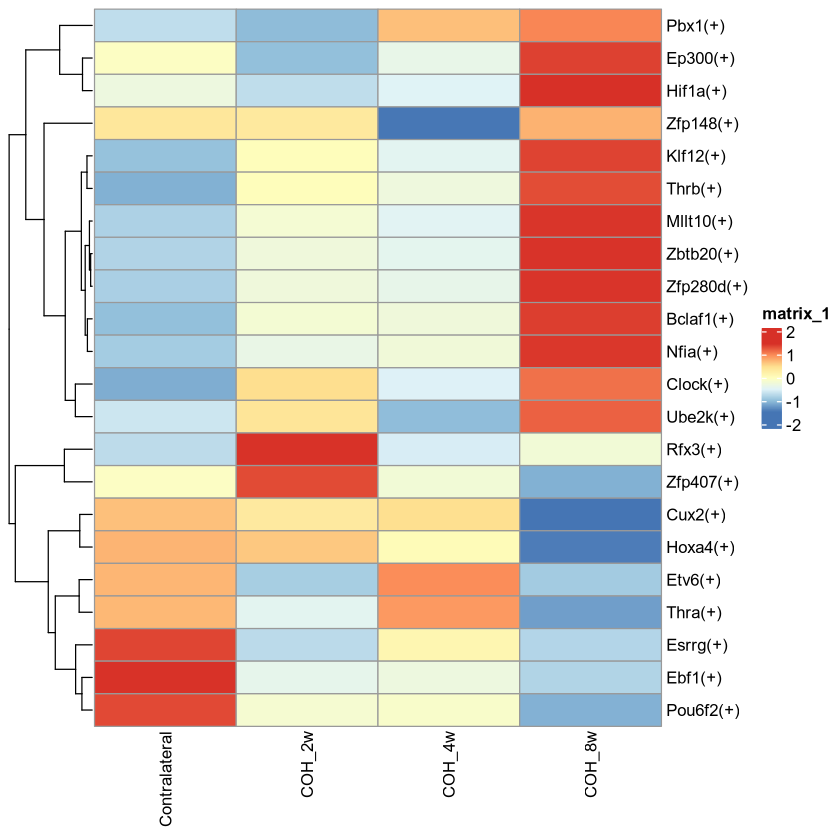

In [7]:
pheatmap(regulonActivity_byGroup_Scaled,cluster_cols = FALSE)

In [9]:
cellinfo <- sce@meta.data[,c('C_scANVI','condition')]
colnames(cellinfo)=c('C_scANVI','condition')
cellTypes <-  as.data.frame(subset(cellinfo,select = 'condition'))
selectedResolution <- "condition"

rss <- calcRSS(AUC=getAUC(sub_regulonAUC),
               cellAnnotation=cellTypes[colnames(sub_regulonAUC),
                                        selectedResolution])

In [11]:
cell_rss <- as.data.frame(rss)

In [12]:
celltype <- colnames(cell_rss)
rssRanklist <- list()

In [13]:
library(ggrepel)
library(ggplot2)

In [16]:
for(i in 1:length(celltype)) {
  data_rank_plot <- cbind(as.data.frame(rownames(cell_rss)),
                          as.data.frame(cell_rss[,celltype[i]]))
  
  colnames(data_rank_plot) <- c("TF","celltype")
  data_rank_plot <- na.omit(data_rank_plot)
  data_rank_plot <- data_rank_plot[order(data_rank_plot$celltype,decreasing = T),]
  data_rank_plot$rank <- seq(1,nrow(data_rank_plot))
  
 p <- ggplot(data_rank_plot,aes(x=rank,y=celltype)) +
    geom_point(size=3,shape=16,color="#1F77B4",alpha=0.4) +
    geom_point(data = data_rank_plot[1:6,],
               size=3,color="#DC050C") + 
    theme_bw() +
    theme(axis.title = element_text(colour = "black", size = 12),
          axis.text = element_text(colour = "black", size = 10),
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank()) +
    labs(x="Rgeulons Rank", y="Specificity Score",title = celltype[i]) +
    geom_text_repel(
    data = data_rank_plot[1:6, ],
    aes(label = TF),
    color = "black",
    size = 2.5,
    fontface = "italic",
    force = 10,
    nudge_x = 30,
    direction = "y",
    box.padding = 0.5,
    point.padding = 0.1,
    arrow = arrow(length = unit(0.015, "npc"), type = "open"),
    segment.color = "grey50",
    segment.size = 0.3,
    segment.alpha = 0.6,
    max.iter = 10000)
    rssRanklist[[i]] <- p
}

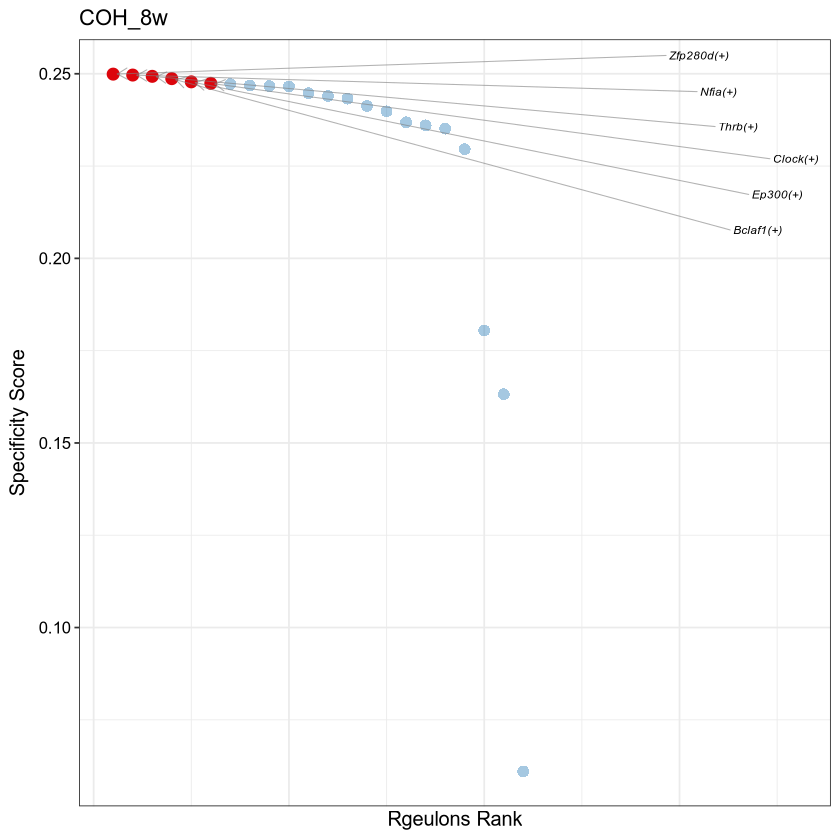

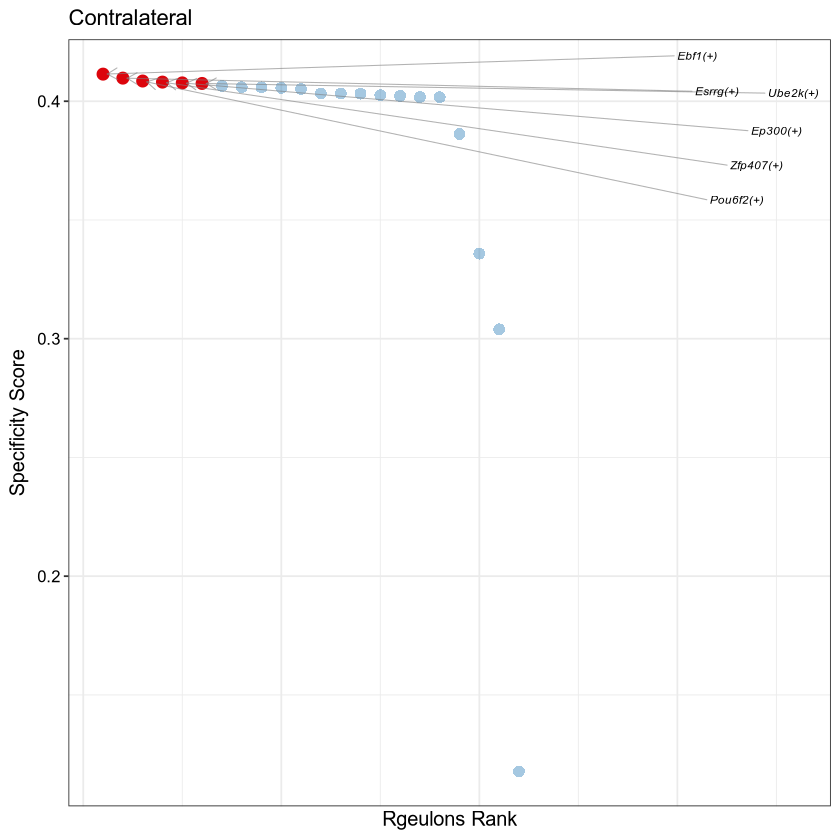

[[1]]

[[2]]

[[3]]

[[4]]


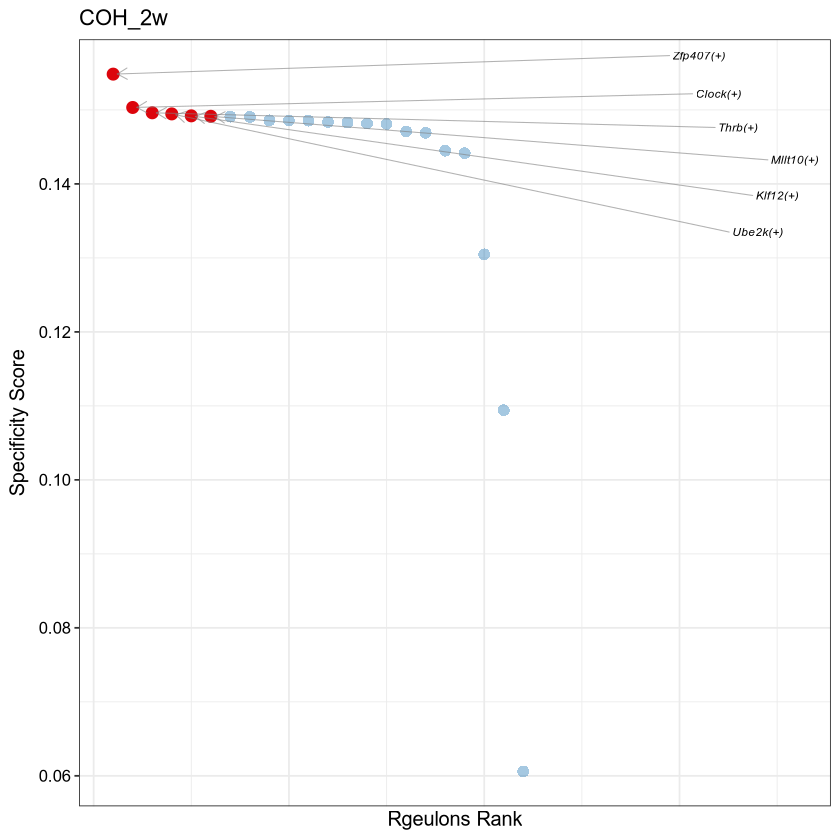

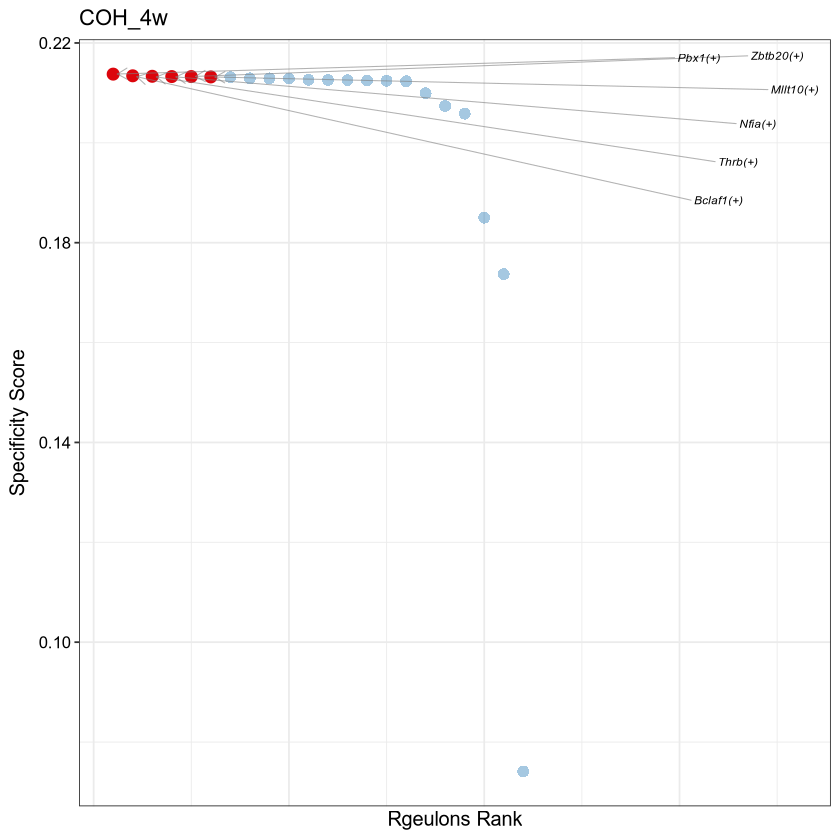

In [17]:
rssRanklist